In [8]:
import pandas as pd

# Load the entire Excel file
file_path = r"D:\College\Simtestlab projects\Drone battery\Drone Battery State of Health\UUT2_BatteryModule_Discharge.xlsx"

xlsx = pd.ExcelFile(file_path)

# Dictionary to store cycles
cycle_data = {}

# Loop through each sheet and load it
for sheet_name in xlsx.sheet_names:
    df_sheet = pd.read_excel(file_path, sheet_name=sheet_name)
    cycle_data[sheet_name] = df_sheet

print("Number of cycles loaded:", len(cycle_data))


Number of cycles loaded: 379


In [ ]:
pip install pandas

In [ ]:
pip install pandas openpyxl

In [9]:
import pandas as pd

file_path = r"D:\College\Simtestlab projects\Drone battery\Drone Battery State of Health\UUT2_BatteryModule_Discharge.xlsx"
xlsx = pd.ExcelFile(file_path)

sheet_lengths = {}

for sheet in xlsx.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    sheet_lengths[sheet] = df.shape[0]  # number of rows

# Show the 20 sheets with the MOST rows
sorted_sheets = sorted(sheet_lengths.items(), key=lambda x: x[1], reverse=True)
sorted_sheets[:20]


[('18', 213),
 ('42', 213),
 ('51', 213),
 ('1', 212),
 ('5', 212),
 ('9', 212),
 ('10', 212),
 ('11', 212),
 ('12', 212),
 ('17', 212),
 ('22', 212),
 ('23', 212),
 ('29', 212),
 ('30', 212),
 ('31', 212),
 ('32', 212),
 ('33', 212),
 ('39', 212),
 ('41', 212),
 ('44', 212)]

In [10]:
import pandas as pd

file_path = r"D:\College\Simtestlab projects\Drone battery\Drone Battery State of Health\UUT2_BatteryModule_Discharge.xlsx"
xlsx = pd.ExcelFile(file_path)

# Build sheet -> row_count dictionary
sheet_lengths = {}
for sheet in xlsx.sheet_names:
    try:
        df = pd.read_excel(file_path, sheet_name=sheet)
        sheet_lengths[sheet] = df.shape[0]
    except Exception as e:
        sheet_lengths[sheet] = 0

# Show a sorted list (descending) so you can see the big sheets first
sorted_desc = sorted(sheet_lengths.items(), key=lambda x: x[1], reverse=True)
print("Top 20 sheets by row count:")
print(sorted_desc[:20])

# Choose sheets with at least 100 rows (adjust threshold if needed)
threshold = 100
valid_sheets = [name for name, cnt in sheet_lengths.items() if cnt >= threshold]
valid_sheets = sorted(valid_sheets, key=lambda x: int(x) if str(x).isdigit() else x)  # sort numerically if names are numbers

print("\nNumber of candidate cycle sheets (rows >= {}): {}".format(threshold, len(valid_sheets)))
print(valid_sheets[:30])  # print the first 30 valid sheet names


Top 20 sheets by row count:
[('18', 213), ('42', 213), ('51', 213), ('1', 212), ('5', 212), ('9', 212), ('10', 212), ('11', 212), ('12', 212), ('17', 212), ('22', 212), ('23', 212), ('29', 212), ('30', 212), ('31', 212), ('32', 212), ('33', 212), ('39', 212), ('41', 212), ('44', 212)]

Number of candidate cycle sheets (rows >= 100): 377
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30']


In [11]:
# Inspect first valid sheet to get column names and preview
rep = valid_sheets[0]
df_rep = pd.read_excel(file_path, sheet_name=rep)
print("Representative sheet:", rep)
print("Shape:", df_rep.shape)
print("Columns:", list(df_rep.columns))
display(df_rep.head())   # use display() in Jupyter; otherwise use print(df_rep.head())


Representative sheet: 1
Shape: (212, 16)
Columns: ['Discharge Cycle #', 'Time\n[s]', 'Voltage\n[V]', 'Test current\n[A]', 'Test capacity\n[Ah]', 'Test power [kW]', 'Test resistance [Ω]', 'UUT2P1 Voltage\n [V ]', 'UUT2P2 Voltage\n[V] ', 'UUT2P3 Voltage\n [V] ', 'UUT2P4 Voltage\n[V] ', 'UUT2P1 Temp\n[⁰C]', 'UUT2P2 Temp\n[⁰C]', 'UUT2P3 Temp\n[⁰C]', 'UUT2P4 Temp\n[⁰C]', 'Ambient Temp\n[⁰C] ']


,Discharge Cycle #,Time\n[s],Voltage\n[V],Test current\n[A],Test capacity\n[Ah],Test power [kW],Test resistance [Ω],UUT2P1 Voltage\n [V ],UUT2P2 Voltage\n[V],UUT2P3 Voltage\n [V],UUT2P4 Voltage\n[V],UUT2P1 Temp\n[⁰C],UUT2P2 Temp\n[⁰C],UUT2P3 Temp\n[⁰C],UUT2P4 Temp\n[⁰C],Ambient Temp\n[⁰C]
0,1,0,84.0,185.7,0.0000,15.6,0.5,22.974,22.298,21.955,21.876,32.495,32.510,32.435,32.150,31.725
1,1,2,83.2,187.5,0.1048,15.6,0.4,21.580,21.493,21.397,21.388,32.850,32.990,32.960,32.530,31.975
2,1,4,82.7,188.6,0.2108,15.6,0.4,21.190,21.182,21.121,21.140,33.440,33.775,33.775,33.190,32.445
3,1,6,82.4,189.3,0.3165,15.6,0.4,21.057,21.041,20.994,21.043,34.210,34.785,34.745,34.035,32.920
4,1,8,82.4,189.3,0.3165,15.6,0.4,21.057,21.041,20.994,21.043,34.970,35.750,35.660,34.860,33.200


In [12]:
# Robust pipeline: auto-detect columns, preprocess cycles, extract features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- EDIT this path if needed ----------
file_path = r"D:\College\Simtestlab projects\Drone battery\Drone Battery State of Health\UUT2_BatteryModule_Discharge.xlsx"
out_csv = "battery_cycle_features.csv"
# ----------------------------------------------

# Read workbook
xlsx = pd.ExcelFile(file_path)
print("Total sheets in workbook:", len(xlsx.sheet_names))

# compute row counts and pick candidate cycle sheets
sheet_lengths = {}
for sheet in xlsx.sheet_names:
    try:
        df_tmp = pd.read_excel(file_path, sheet_name=sheet)
        sheet_lengths[sheet] = df_tmp.shape[0]
    except Exception as e:
        sheet_lengths[sheet] = 0

threshold_rows = 100
valid_sheets = [s for s,c in sheet_lengths.items() if c >= threshold_rows]

def _sort_key(s):
    try:
        return int(s)
    except:
        return s
valid_sheets = sorted(valid_sheets, key=_sort_key)
print(f"Candidate cycle sheets (rows >= {threshold_rows}): {len(valid_sheets)}. Example:", valid_sheets[:8])

# helper: normalize column names for a dataframe
def normalize_cols(df):
    new_cols = []
    for c in df.columns:
        # convert bytes etc to str, then remove newlines, extra spaces
        s = str(c)
        s = s.replace("\n", " ").replace("\r", " ").strip()
        # collapse multiple spaces
        s = " ".join(s.split())
        new_cols.append(s)
    df.columns = new_cols
    return df

# Auto-detect column names by scanning a representative sheet's normalized columns
sample_df = normalize_cols(pd.read_excel(file_path, sheet_name=valid_sheets[0]))
print("\nNormalized sample columns (first sheet):")
print(sample_df.columns.tolist())

# Find best-match column names by simple substring rules
def find_column(cols, candidates):
    """Return first column in cols containing any candidate substring (case-ins)."""
    cols_lc = [c.lower() for c in cols]
    for cand in candidates:
        cand_lc = cand.lower()
        for i,c in enumerate(cols_lc):
            if cand_lc in c:
                return cols[i]
    return None

cols_list = sample_df.columns.tolist()

VCOL_candidates = ["voltage", "voltage [v]", "module voltage", "voltage (v)"]
ICOL_candidates = ["current", "test current", "test current [a]", "discharge current"]
CAPCOL_candidates = ["capacity", "test capacity", "capacity [ah]", "discharged capacity", "test capacity [ah]"]
TIMECOL_candidates = ["time", "time [s]", "time (s)"]

VCOL = find_column(cols_list, VCOL_candidates)
ICOL = find_column(cols_list, ICOL_candidates)
CAPCOL = find_column(cols_list, CAPCOL_candidates)
TIMECOL = find_column(cols_list, TIMECOL_candidates)

print("\nAuto-detected columns:")
print("Voltage column ->", VCOL)
print("Current column ->", ICOL)
print("Capacity column ->", CAPCOL)
print("Time column ->", TIMECOL)

# If any required column not found, show all normalized columns to help you edit
if VCOL is None or ICOL is None:
    print("\nERROR: Could not auto-detect Voltage and/or Current columns.")
    print("Normalized columns available (copy the exact name and update the detection lists if needed):")
    print(cols_list)
    raise SystemExit("Please update the VCOL/ICOL detection candidates or set names manually.")

# thresholds (adjust based on your battery)
takeoff_current_thresh = 200.0   # A — remove > this (takeoff spike)
cruise_current_thresh = 5.0      # A — remove < this (cruise or near-zero)
voltage_low = 87.6               # V (3.65 * 24)
voltage_high = 90.0              # V (3.75 * 24)
min_points = 10                  # skip cycle if too few points after filtering

rows_features = []
skipped_sheets = []

for sheet in valid_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet)
    df = normalize_cols(df)

    # confirm required columns exist in this sheet
    if VCOL not in df.columns or ICOL not in df.columns:
        skipped_sheets.append(sheet)
        # print minimal info for debugging
        print(f"Skipping sheet {sheet}: missing V or I column in this sheet.")
        continue

    # coerce numeric and drop NaNs in essential columns
    df[VCOL] = pd.to_numeric(df[VCOL], errors='coerce')
    df[ICOL] = pd.to_numeric(df[ICOL], errors='coerce')
    df = df.dropna(subset=[VCOL, ICOL]).copy()

    # read capacity if present
    capacity_val = np.nan
    if CAPCOL and CAPCOL in df.columns:
        df[CAPCOL] = pd.to_numeric(df[CAPCOL], errors='coerce')
        capacity_val = df[CAPCOL].max()

    # 1) remove takeoff (very high current)
    df = df[df[ICOL].abs() <= takeoff_current_thresh]
    # 2) remove cruise (very low absolute current)
    df = df[df[ICOL].abs() >= cruise_current_thresh]
    # 3) select voltage window
    df = df[(df[VCOL] >= voltage_low) & (df[VCOL] <= voltage_high)]

    if df.shape[0] < min_points:
        skipped_sheets.append(sheet)
        # optionally print reason:
        #print(f"Sheet {sheet} skipped: {df.shape[0]} rows after filtering.")
        continue

    # 4) compute InV using absolute current (handle sign conventions)
    df['InV'] = (df[ICOL].abs() ** 0.05) * df[VCOL]

    # 5) extract features
    mean_inv = df['InV'].mean()
    max_inv = df['InV'].max()
    min_inv = df['InV'].min()
    std_inv = df['InV'].std()
    slope = (df['InV'].iloc[-1] - df['InV'].iloc[0]) / max(1, (len(df)-1))
    if TIMECOL and TIMECOL in df.columns:
        try:
            x_time = pd.to_numeric(df[TIMECOL], errors='coerce').values
            auc = np.trapz(df['InV'].values, x=x_time)
        except:
            auc = np.trapz(df['InV'].values)
    else:
        auc = np.trapz(df['InV'].values)

    rows_features.append({
        "sheet": sheet,
        "nrows_after_filter": int(df.shape[0]),
        "mean_inv": float(mean_inv),
        "max_inv": float(max_inv),
        "min_inv": float(min_inv),
        "std_inv": float(std_inv),
        "slope": float(slope),
        "auc": float(auc),
        "capacity": float(capacity_val) if not np.isnan(capacity_val) else np.nan
    })

# Build DataFrame
feat_df = pd.DataFrame(rows_features)
if feat_df.empty:
    raise SystemExit("No cycles processed. Check thresholds and column detection.")

# sort by numeric sheet name when possible
try:
    feat_df['sheet_int'] = feat_df['sheet'].astype(int)
    feat_df = feat_df.sort_values('sheet_int').drop(columns='sheet_int')
except:
    feat_df = feat_df.sort_values('sheet')

# Compute SOH if capacity available
if 'capacity' in feat_df.columns and feat_df['capacity'].notna().any():
    first_cap = feat_df['capacity'].dropna().iloc[0]
    feat_df['SOH'] = (feat_df['capacity'] / first_cap) * 100.0
else:
    feat_df['SOH'] = np.nan

feat_df.to_csv(out_csv, index=False)
print("Feature extraction complete. Output saved to:", Path(out_csv).resolve())
print("Processed cycles (rows in feature table):", len(feat_df))
print("Sheets skipped:", len(skipped_sheets))
if skipped_sheets:
    print("Example skipped sheets:", skipped_sheets[:10])

# Quick plot of SOH if present
if feat_df['SOH'].notna().any():
    plt.figure(figsize=(9,4))
    plt.plot(feat_df['SOH'].values, marker='o', linestyle='-')
    plt.title("SOH vs Cycle (derived from capacity column)")
    plt.ylabel("SOH (%)")
    plt.xlabel("Cycle index (ordered by sheet)")
    plt.grid(True)
    plt.show()

# Preview table
display(feat_df.head())


Total sheets in workbook: 379
Candidate cycle sheets (rows >= 100): 377. Example: ['1', '2', '3', '4', '5', '6', '7', '8']

Normalized sample columns (first sheet):
['Discharge Cycle #', 'Time [s]', 'Voltage [V]', 'Test current [A]', 'Test capacity [Ah]', 'Test power [kW]', 'Test resistance [Ω]', 'UUT2P1 Voltage [V ]', 'UUT2P2 Voltage [V]', 'UUT2P3 Voltage [V]', 'UUT2P4 Voltage [V]', 'UUT2P1 Temp [⁰C]', 'UUT2P2 Temp [⁰C]', 'UUT2P3 Temp [⁰C]', 'UUT2P4 Temp [⁰C]', 'Ambient Temp [⁰C]']

Auto-detected columns:
Voltage column -> Voltage [V]
Current column -> Test current [A]
Capacity column -> Test capacity [Ah]
Time column -> Time [s]


C:\Users\priya\AppData\Local\Temp\ipykernel_24448\1280605622.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(df['InV'].values, x=x_time)
C:\Users\priya\AppData\Local\Temp\ipykernel_24448\1280605622.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(df['InV'].values, x=x_time)
C:\Users\priya\AppData\Local\Temp\ipykernel_24448\1280605622.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(df['InV'].values, x=x_time)
C:\Users\priya\AppData\Local\Temp\ipykernel_24448\1280605622.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(df['InV'].values, x=x_time)


KeyboardInterrupt: 

In [ ]:
pip install matplotlib

In [14]:
import pandas as pd

df = pd.read_csv("battery_cycle_features.csv")
print(df.head())
print(df.shape)


   sheet  nrows_after_filter    mean_inv     max_inv     min_inv   std_inv  \
0      1                  29  108.828132  112.346522  105.858122  2.482591   
1      2                  26  109.053639  112.228337  105.976931  2.340196   
2      3                  27  109.206421  112.346522  106.095739  2.324056   
3      4                  26  109.194975  112.346522  106.095739  2.369305   
4      5                  27  109.210901  112.346522  106.197608  2.254379   

      slope          auc  capacity         SOH  
0 -0.219604  9325.700089    4.6076  100.000000  
1 -0.236478  8253.496964    4.5439   98.617502  
2 -0.231928  8265.681014    4.4110   95.733137  
3 -0.241205  8048.097193    4.5168   98.029343  
4 -0.227359  8051.324940    4.4689   96.989756  
(377, 10)


In [15]:
# Select feature columns
feature_cols = ["mean_inv", "max_inv", "min_inv", "std_inv", "slope", "auc"]

X = df[feature_cols]
y = df["SOH"]


In [16]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)


In [ ]:
pip install scikit-learn

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_pred = model.predict(X_test)


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE: 1.4137831909036045
RMSE: 1.9998708355589172
R² Score: 0.8714865753441279


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

model = pipeline.named_steps["model"]


np.abs(model.coef_)

# Feature importance for linear regression
import pandas as pd
import numpy as np

linear_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": model.coef_,
    "Importance": np.abs(model.coef_)
}).sort_values(by="Importance", ascending=False)

print("Linear Regression Feature Importance:")
linear_importance


Linear Regression Feature Importance:


,Feature,Coefficient,Importance
3,std_inv,-3.035331,3.035331
4,slope,2.830906,2.830906
2,min_inv,-1.896195,1.896195
1,max_inv,1.867381,1.867381
5,auc,-1.592250,1.592250
0,mean_inv,1.444155,1.444155


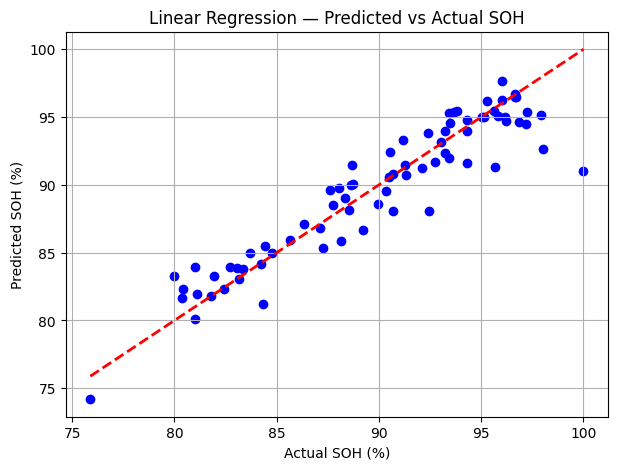

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.xlabel("Actual SOH (%)")
plt.ylabel("Predicted SOH (%)")
plt.title("Linear Regression — Predicted vs Actual SOH")
plt.grid(True)
plt.show()


In [ ]:
coef = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_
})
print(coef)


    feature  coefficient
0  mean_inv     6.169366
1   max_inv     4.345804
2   min_inv    -6.017880
3   std_inv   -20.595045
4     slope    96.532456
5       auc    -0.000442


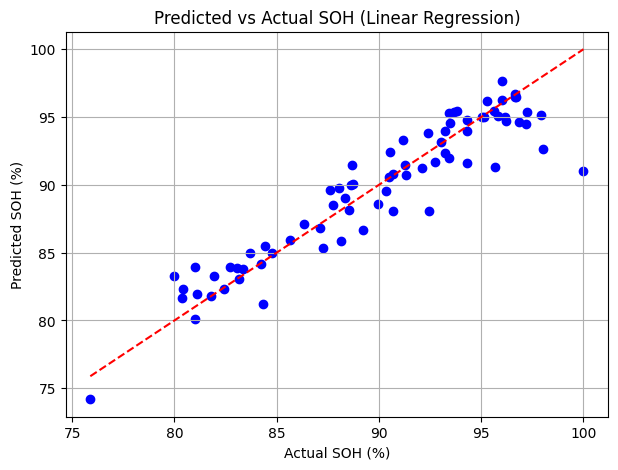

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual SOH (%)")
plt.ylabel("Predicted SOH (%)")
plt.title("Predicted vs Actual SOH (Linear Regression)")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Accuracy metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Accuracy Metrics:")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R² Score:", r2)


Model Accuracy Metrics:
MAE  : 1.4137831909036045
RMSE : 1.9998708355589172
R² Score: 0.8714865753441279


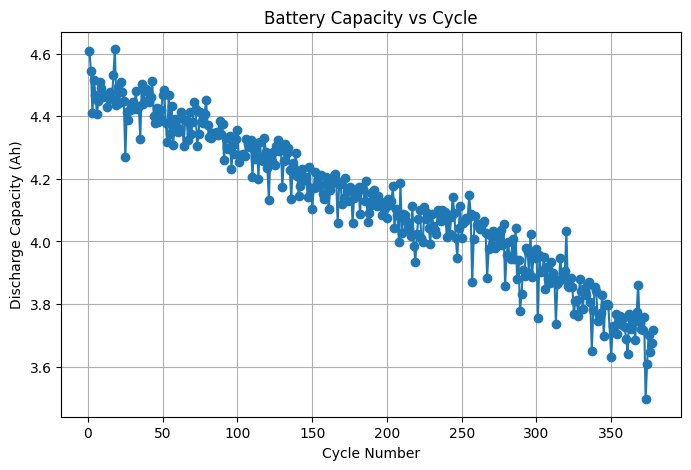

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("battery_cycle_features.csv")

plt.figure(figsize=(8,5))
plt.plot(df["sheet"].astype(int), df["capacity"], marker='o')
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (Ah)")
plt.title("Battery Capacity vs Cycle")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

file_path = r"D:\College\Simtestlab projects\Drone battery\Drone Battery State of Health\UUT2_BatteryModule_Discharge.xlsx"

def clean_cols(df):
    df.columns = [c.replace("\n"," ").strip() for c in df.columns]
    return df


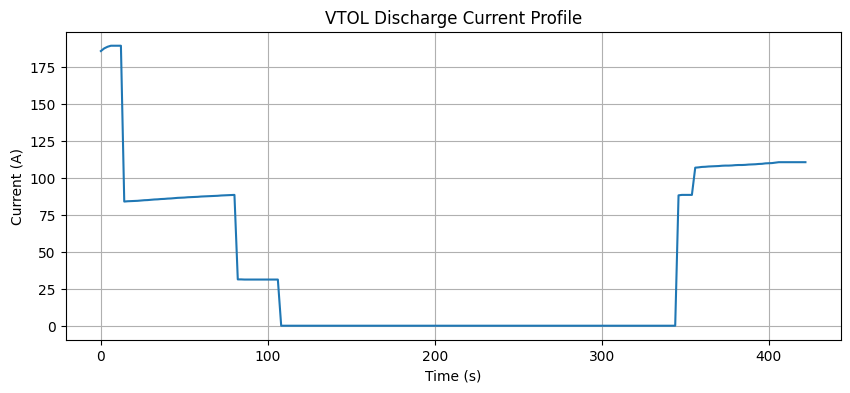

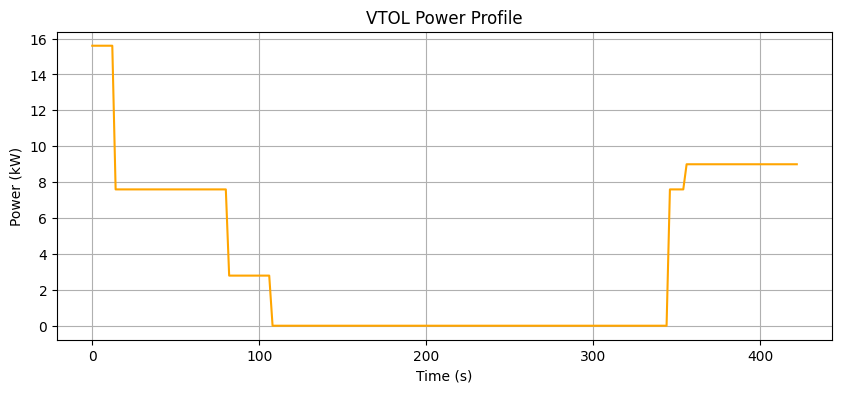

In [ ]:
#Analyze VTOL Discharge Current & Power Profile
file_path_all = r"D:\College\Simtestlab projects\Drone battery\final battery dataset\UUT2_BatteryModule_Discharge.xlsx"
df1 = clean_cols(pd.read_excel(file_path_all, sheet_name="1"))

plt.figure(figsize=(10,4))
plt.plot(df1["Time [s]"], df1["Test current [A]"], label="Current (A)")
plt.title("VTOL Discharge Current Profile")
plt.ylabel("Current (A)")
plt.xlabel("Time (s)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(df1["Time [s]"], df1["Test power [kW]"], color="orange", label="Power (kW)")
plt.title("VTOL Power Profile")
plt.ylabel("Power (kW)")
plt.xlabel("Time (s)")
plt.grid(True)
plt.show()


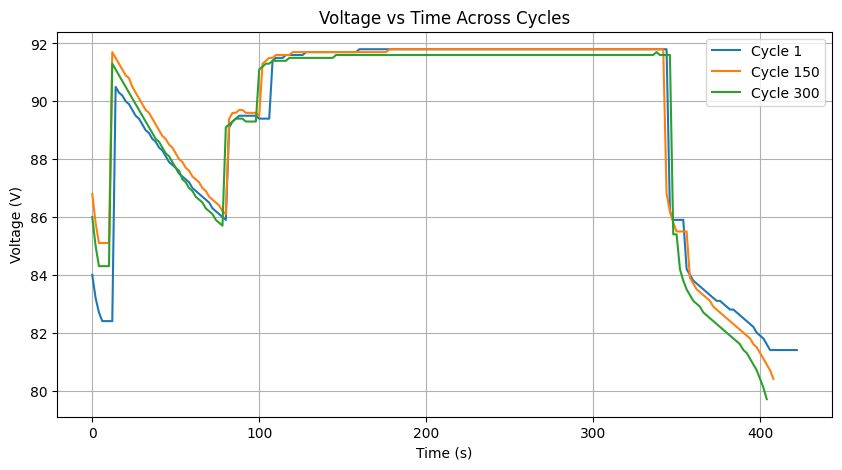

In [ ]:
#Plot Voltage vs Time for Selected Cycles
cycles_to_plot = ["1", "150", "300"]

plt.figure(figsize=(10,5))
for c in cycles_to_plot:
    df = clean_cols(pd.read_excel(file_path_all, sheet_name=c))
    plt.plot(df["Time [s]"], df["Voltage [V]"], label=f"Cycle {c}")

plt.title("Voltage vs Time Across Cycles")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.legend()
plt.show()


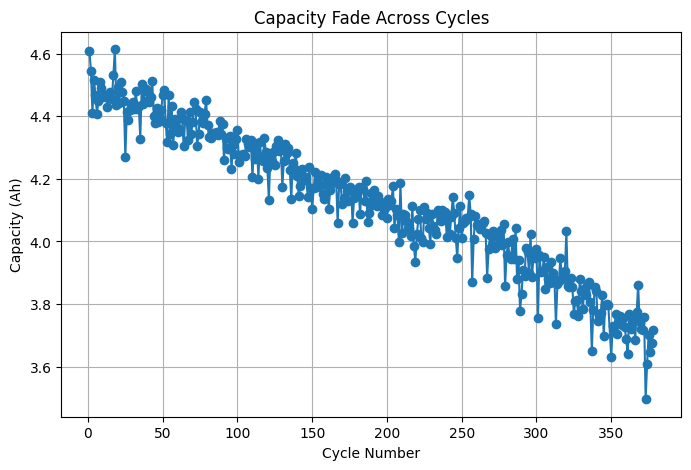

In [ ]:
# Plot Capacity Fade Across All Cycles

df_feat = pd.read_csv("battery_cycle_features.csv")

plt.figure(figsize=(8,5))
plt.plot(df_feat["sheet"].astype(int), df_feat["capacity"], marker='o')
plt.title("Capacity Fade Across Cycles")
plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.grid(True)
plt.show()


C:\Users\priya\AppData\Local\Temp\ipykernel_5240\585515180.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(df["Test power [kW]"], x=df["Time [s]"])
C:\Users\priya\AppData\Local\Temp\ipykernel_5240\585515180.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(df["Test power [kW]"], x=df["Time [s]"])
C:\Users\priya\AppData\Local\Temp\ipykernel_5240\585515180.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(df["Test power [kW]"], x=df["Time [s]"])
C:\Users\priya\AppData\Local\Temp\ipykernel_5240\585515180.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np

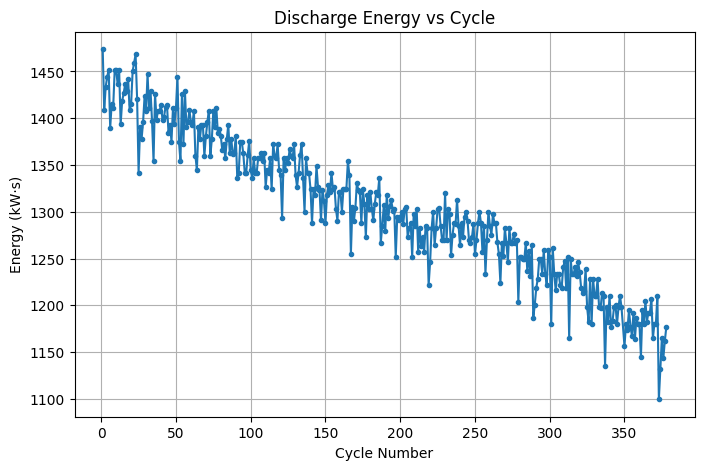

In [ ]:
#Plot Discharge Energy vs Cycle

energies = []

for sheet in df_feat["sheet"].astype(str):
    df = clean_cols(pd.read_excel(file_path, sheet_name=sheet))
    # Use np.trapezoid instead of np.trapz
    energy = np.trapezoid(df["Test power [kW]"], x=df["Time [s]"])
    energies.append(energy)

plt.figure(figsize=(8,5))
plt.plot(df_feat["sheet"].astype(int), energies, marker='.')
plt.title("Discharge Energy vs Cycle")
plt.xlabel("Cycle Number")
plt.ylabel("Energy (kW·s)")
plt.grid(True)
plt.show()


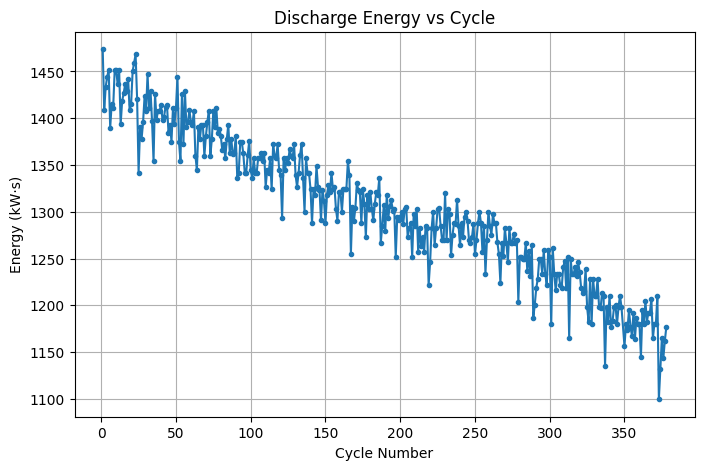

In [ ]:
# Plot Discharge Energy vs Cycle

energies = []

for sheet in df_feat["sheet"].astype(str):
    df = clean_cols(pd.read_excel(file_path, sheet_name=sheet))
    energy = np.trapezoid(df["Test power [kW]"], x=df["Time [s]"])
    energies.append(energy)

plt.figure(figsize=(8,5))
plt.plot(df_feat["sheet"].astype(int), energies, marker='.')
plt.title("Discharge Energy vs Cycle")
plt.xlabel("Cycle Number")
plt.ylabel("Energy (kW·s)")
plt.grid(True)
plt.show()


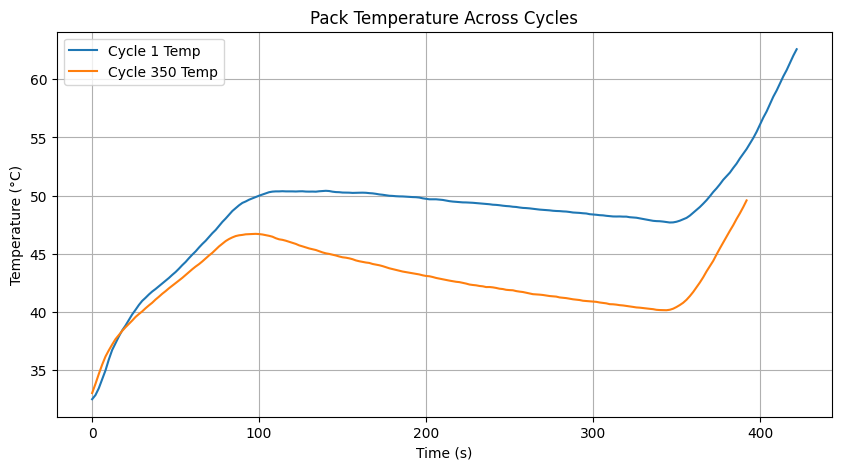

In [ ]:
# Analyze Temperature Behavior

df_early = clean_cols(pd.read_excel(file_path, sheet_name="1"))
df_late  = clean_cols(pd.read_excel(file_path, sheet_name="350"))

plt.figure(figsize=(10,5))
plt.plot(df_early["Time [s]"], df_early["UUT2P1 Temp [⁰C]"], label="Cycle 1 Temp")
plt.plot(df_late["Time [s]"],  df_late["UUT2P1 Temp [⁰C]"], label="Cycle 350 Temp")
plt.title("Pack Temperature Across Cycles")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()


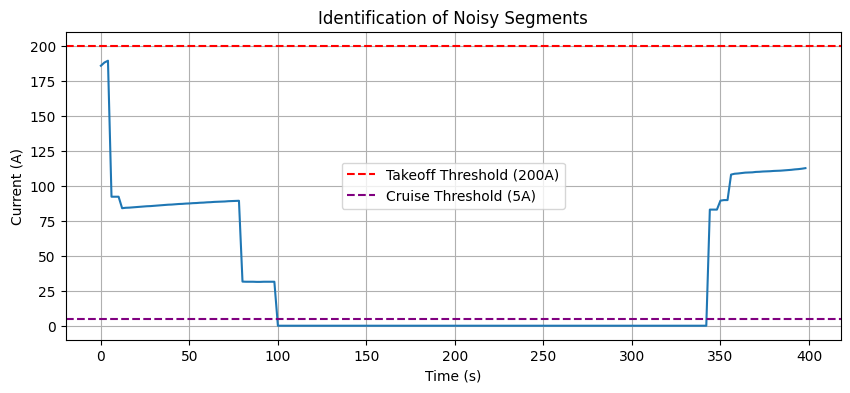

In [ ]:
# Identify Noisy Segments (Takeoff & Cruise)

plt.figure(figsize=(10,4))
plt.plot(df["Time [s]"], df["Test current [A]"])

# Visual markers
plt.axhline(200, color='red', linestyle='--', label="Takeoff Threshold (200A)")
plt.axhline(5, color='purple', linestyle='--', label="Cruise Threshold (5A)")

plt.title("Identification of Noisy Segments")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.legend()
plt.grid(True)
plt.show()


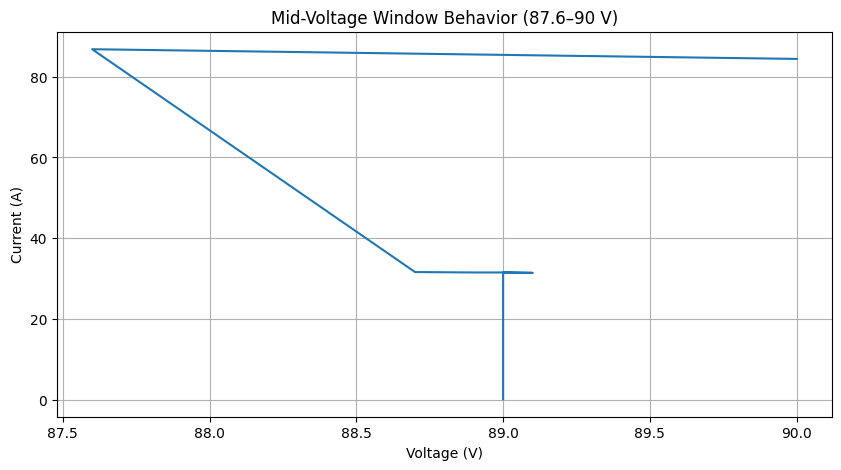

In [ ]:
# Inspect Mid-Voltage Window Behavior (87.6–90V)

df1_window = df[(df["Voltage [V]"] >= 87.6) & (df["Voltage [V]"] <= 90.0)]

plt.figure(figsize=(10,5))
plt.plot(df1_window["Voltage [V]"], df1_window["Test current [A]"])
plt.title("Mid-Voltage Window Behavior (87.6–90 V)")
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.grid(True)
plt.show()


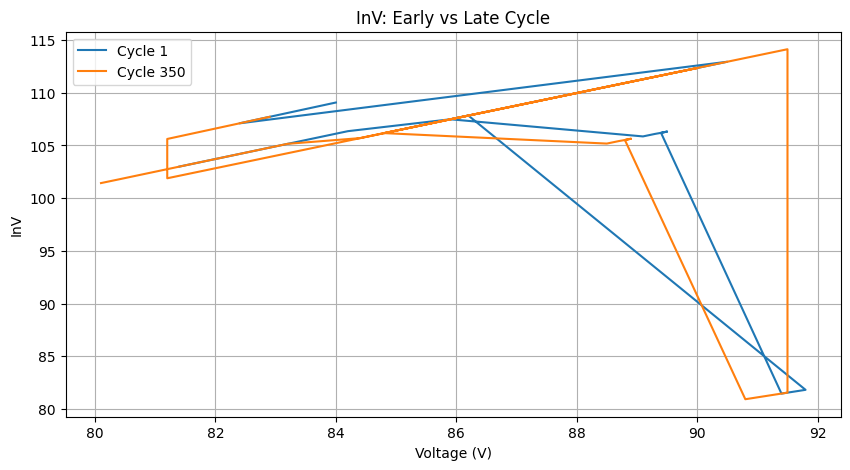

In [ ]:
# Compare Early vs Late InV Curves
df_early["InV"] = (df_early["Test current [A]"].abs()**0.05) * df_early["Voltage [V]"]
df_late["InV"]  = (df_late["Test current [A]"].abs()**0.05) * df_late["Voltage [V]"]

plt.figure(figsize=(10,5))
plt.plot(df_early["Voltage [V]"], df_early["InV"], label="Cycle 1")
plt.plot(df_late["Voltage [V]"], df_late["InV"],  label="Cycle 350")
plt.title("InV: Early vs Late Cycle")
plt.xlabel("Voltage (V)")
plt.ylabel("InV")
plt.grid(True)
plt.legend()
plt.show()


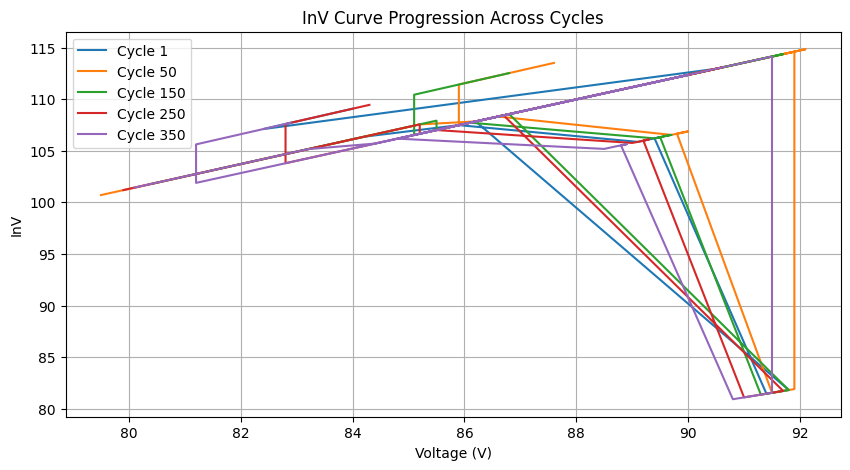

In [ ]:
# Examine Degradation Patterns Across Multiple Cycles

cycles = ["1", "50", "150", "250", "350"]

plt.figure(figsize=(10,5))

for c in cycles:
    df = clean_cols(pd.read_excel(file_path, sheet_name=c))
    df["InV"] = (df["Test current [A]"].abs()**0.05) * df["Voltage [V]"]
    plt.plot(df["Voltage [V]"], df["InV"], label=f"Cycle {c}")

plt.title("InV Curve Progression Across Cycles")
plt.xlabel("Voltage (V)")
plt.ylabel("InV")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [23]:
from sklearn.model_selection import train_test_split

FEATURES = [
    "mean_inv",
    "max_inv",
    "min_inv",
    "std_inv",
    "slope",
    "auc"
]

X = df[FEATURES]
y = df["SOH"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)




In [ ]:
globals().keys()



dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'FEATURES', '_i2', '_i3', '_i4', 'pd', 'np', 'plt', 'Path', 'file_path', 'out_csv', 'xlsx', 'sheet_lengths', 'sheet', 'df_tmp', 'threshold_rows', 'valid_sheets', '_sort_key', 'normalize_cols', 'sample_df', 'find_column', 'cols_list', 'VCOL_candidates', 'ICOL_candidates', 'CAPCOL_candidates', 'TIMECOL_candidates', 'VCOL', 'ICOL', 'CAPCOL', 'TIMECOL', 'takeoff_current_thresh', 'cruise_current_thresh', 'voltage_low', 'voltage_high', 'min_points', 'rows_features', 'skipped_sheets', 'df', 'capacity_val', 'mean_inv', 'max_inv', 'min_inv', 'std_inv', 'slope', 'x_time', 'auc', 'feat_df', 'first_cap', '_i5', 'cycle_data', 'sheet_name', 'df_sheet', '_i6', 'Ridge', '_i7', 'StandardScaler', 'mean_absolute_error', 'mean_squared_error', 'r2_score', 'scaler'

In [24]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np



scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Train model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Predict
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluate
print("Ridge Regression Performance")
print("MAE  :", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R²   :", r2_score(y_test, y_pred_ridge))


Ridge Regression Performance
MAE  : 1.4232653900163499
RMSE : 2.0203635057658627
R²   : 0.8688393279908175


In [25]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": np.abs(ridge.coef_)
}).sort_values(by="Importance", ascending=False)

print("Ridge Feature Importance:")
feature_importance


Ridge Feature Importance:


,Feature,Importance
3,std_inv,2.813081
4,slope,2.726076
1,max_inv,1.721818
2,min_inv,1.582424
5,auc,1.520140
0,mean_inv,1.460855


In [27]:
# Lasso Regression Performance


from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train Lasso model
lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# Predict
y_pred_lasso = lasso.predict(X_test_scaled)

# Evaluate
print("Lasso Regression Performance")
print("MAE  :", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R²   :", r2_score(y_test, y_pred_lasso))


Lasso Regression Performance
MAE  : 1.41440569537814
RMSE : 2.0027145336998426
R²   : 0.8711208385106939


In [28]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": np.abs(lasso.coef_)
}).sort_values(by="Importance", ascending=False)

print("Lasso Feature Importance:")
feature_importance


Lasso Feature Importance:


,Feature,Importance
3,std_inv,3.006958
4,slope,2.813494
2,min_inv,1.849703
1,max_inv,1.846545
5,auc,1.580215
0,mean_inv,1.442253


In [29]:
# Random Forest Regressor Performance



from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train Random Forest model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Regressor Performance")
print("MAE  :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²   :", r2_score(y_test, y_pred_rf))


Random Forest Regressor Performance
MAE  : 1.3373316472412842
RMSE : 2.302007051273268
R²   : 0.8297222503637726


In [30]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Random Forest Feature Importance:")
feature_importance


Random Forest Feature Importance:


,Feature,Importance
3,std_inv,0.849436
5,auc,0.056894
0,mean_inv,0.048749
4,slope,0.030343
2,min_inv,0.012730
1,max_inv,0.001849


In [ ]:
pip install xgboost


In [31]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize XGBoost Regressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

from sklearn.model_selection import train_test_split



FEATURES = [
    "mean_inv",
    "max_inv",
    "min_inv",
    "std_inv",
    "slope",
    "auc"
]

X = df[FEATURES]
y = df["SOH"]



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)




# Train model
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Evaluate
print("XGBoost Regressor Performance")
print("MAE  :", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R²   :", r2_score(y_test, y_pred_xgb))


XGBoost Regressor Performance
MAE  : 1.365644260770969
RMSE : 2.312315200288678
R²   : 0.8281938637964571


In [32]:
import pandas as pd

xgb_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print('XGBoost Feature Importance:')

xgb_importance


XGBoost Feature Importance:


,Feature,Importance
3,std_inv,0.463737
2,min_inv,0.303246
0,mean_inv,0.088979
4,slope,0.084917
5,auc,0.044170
1,max_inv,0.014950


In [36]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store all results
results = {
    "Model": [],
    "MAE (%)": [],
    "RMSE (%)": [],
    "R² Score": []
}

# Helper function to add model metrics to table
def add_results(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results["Model"].append(name)
    results["MAE (%)"].append(round(mae, 4))
    results["RMSE (%)"].append(round(rmse, 4))
    results["R² Score"].append(round(r2, 4))

# Add each model here
add_results("Linear Regression", y_test, y_pred)
add_results("Ridge Regression", y_test, y_pred_ridge)
add_results("Lasso Regression", y_test, y_pred_lasso)
add_results("Random Forest", y_test, y_pred_rf)
add_results("XGBoost", y_test, y_pred_xgb)

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Display table
results_df


,Model,MAE (%),RMSE (%),R² Score
0,Linear Regression,1.4138,1.9999,0.8715
1,Ridge Regression,1.4233,2.0204,0.8688
2,Lasso Regression,1.4144,2.0027,0.8711
3,Random Forest,1.3373,2.3020,0.8297
4,XGBoost,1.3656,2.3123,0.8282
